# RGB-D Pipeline

Using **DepthAnythingv2** metric to estimate depth

In [2]:
import torch
import cv2
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoImageProcessor, AutoModelForDepthEstimation
import open3d as o3d
import sys
sys.path.append("../")
from utils.imageSelector import select_equally_distributed_images

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## Loading and viewing images

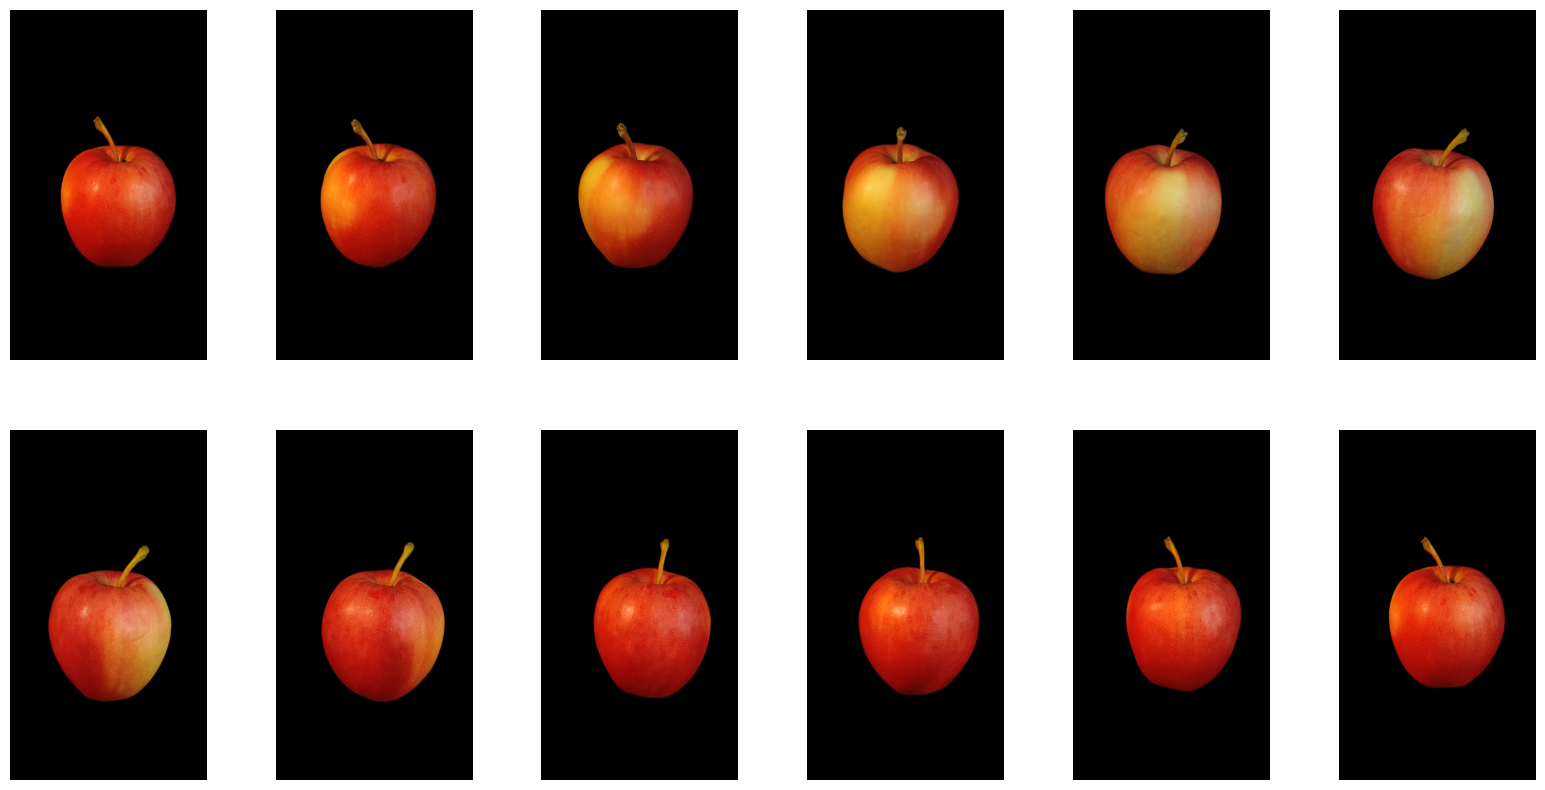

In [3]:
# Import images

input_dir = "../data/images"
image_paths = select_equally_distributed_images(input_dir, n = 13)[0:12]

# Load images and display them

images = [Image.open(path).convert("RGB") for path in image_paths]

f, axarr = plt.subplots(2,6, figsize=(20,10))
for i, img in enumerate(images):
    axarr[i//6, i%6].imshow(img)
    axarr[i//6, i%6].axis('off')
plt.show()


## Generating the Depth Images

In [4]:
# Loading the model

model_path = "depth-anything/Depth-Anything-V2-Metric-Indoor-Large-hf"
processor = AutoImageProcessor.from_pretrained(model_path)
model = AutoModelForDepthEstimation.from_pretrained(model_path).eval()

Loading weights:   0%|          | 0/503 [00:00<?, ?it/s]

In [5]:
# Generate depth maps

depth_maps = []
for image in images:
    inputs = processor(images=image, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
        predicted_depth = outputs.predicted_depth.squeeze().cpu().numpy()
    
    # Resize to match input resolution
    predicted_depth_resized = cv2.resize(predicted_depth, (image.width, image.height))
    
    depth_maps.append(predicted_depth_resized)

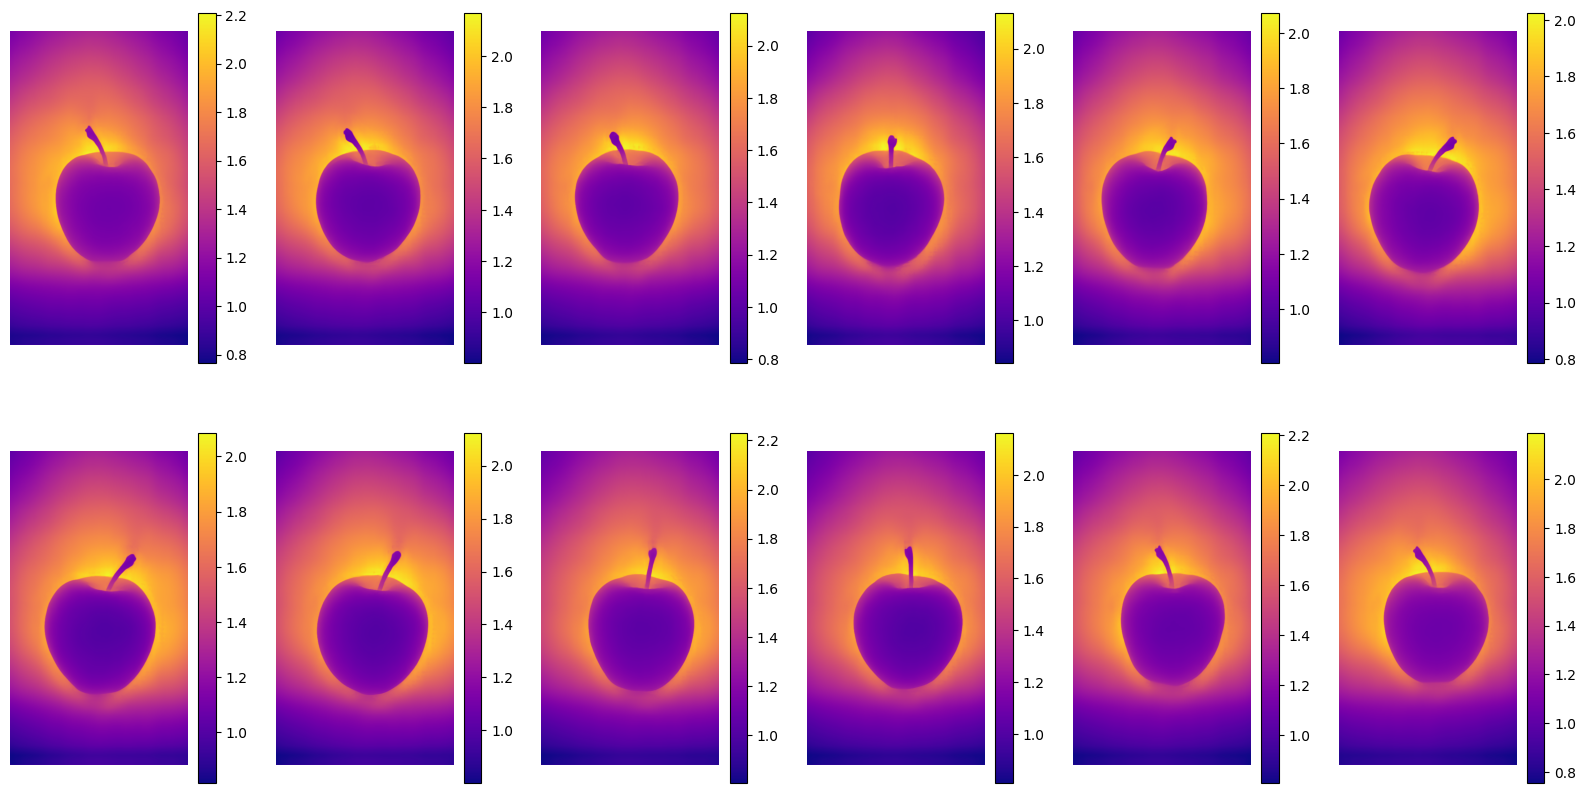

In [6]:
# Visualize the depth maps

f, axarr = plt.subplots(2,6, figsize=(20,10))
for i, img in enumerate(depth_maps):
    im = axarr[i//6, i%6].imshow(img, cmap='plasma')
    axarr[i//6, i%6].axis('off')
    f.colorbar(im, ax=axarr[i//6, i%6])
plt.show()


## Merge the images to produce RGBD

In [9]:
# Merge the RGB and depth information to create a RGBD image

rgbd_images = []
for img, depth in zip(images, depth_maps):
    rgbd = np.dstack((np.array(img), depth))
    rgbd_images.append(rgbd)

## Helpers

In [10]:
import copy
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ─── Backprojection ────────────────────────────────────────────────────────────
def backproject_depth_to_points(depth, fx, fy, cx, cy, depth_min=0.1, depth_max=10.0):
    """Backproject a depth map to a (N,3) array of 3-D camera-frame points."""
    H, W = depth.shape
    u, v = np.meshgrid(np.arange(W), np.arange(H))
    z = depth
    mask = (z > depth_min) & (z < depth_max)
    x = (u - cx) * z / fx
    y = (v - cy) * z / fy
    pts = np.stack([x, y, z], axis=-1).reshape(-1, 3)
    return pts, mask.reshape(-1)


# ─── Rigid transform utilities ─────────────────────────────────────────────────
def apply_transform(T, pts):
    """Apply a 4×4 rigid transform to an (N,3) point array."""
    return (T[:3, :3] @ pts.T).T + T[:3, 3]


def estimate_rigid_transform_svd(src, tgt):
    """
    Optimal rigid transform T such that tgt ≈ T @ src  (Horn 1987, SVD method).
    Returns a 4×4 matrix.
    """
    mu_s, mu_t = src.mean(0), tgt.mean(0)
    H = (src - mu_s).T @ (tgt - mu_t)
    U, _, Vt = np.linalg.svd(H)
    d = np.linalg.det(Vt.T @ U.T)
    R = Vt.T @ np.diag([1.0, 1.0, d]) @ U.T   # reflection-safe
    t = mu_t - R @ mu_s
    T = np.eye(4)
    T[:3, :3] = R
    T[:3, 3]  = t
    return T


# ─── 3-D SIFT features ─────────────────────────────────────────────────────────
def extract_sift_features_3d(rgb_image, depth_map, fx, fy, cx, cy,
                              depth_min=0.1, depth_max=10.0, n_features=2000):
    """
    Detect SIFT keypoints in rgb_image and lift them to 3-D using depth_map.

    Returns
    -------
    kps      : list of cv2.KeyPoint (only those with valid depth)
    descs    : (N,128) float32 descriptor array
    pts3d    : (N,3) array in camera coordinates
    """
    gray = cv2.cvtColor(np.array(rgb_image), cv2.COLOR_RGB2GRAY)
    sift = cv2.SIFT_create(nfeatures=n_features)
    kps, descs = sift.detectAndCompute(gray, None)

    if descs is None or len(kps) == 0:
        return [], np.empty((0, 128), dtype=np.float32), np.empty((0, 3))

    valid_kps, valid_descs, valid_pts3d = [], [], []
    for kp, desc in zip(kps, descs):
        u, v = int(round(kp.pt[0])), int(round(kp.pt[1]))
        if 0 <= v < depth_map.shape[0] and 0 <= u < depth_map.shape[1]:
            z = float(depth_map[v, u])
            if depth_min < z < depth_max:
                valid_kps.append(kp)
                valid_descs.append(desc)
                valid_pts3d.append([(u - cx)*z/fx, (v - cy)*z/fy, z])

    if not valid_pts3d:
        return [], np.empty((0, 128), dtype=np.float32), np.empty((0, 3))

    return valid_kps, np.array(valid_descs, dtype=np.float32), np.array(valid_pts3d)


# ─── Feature matching (Lowe ratio test) ────────────────────────────────────────
def match_sift_features(descs1, descs2, ratio=0.75):
    """
    BFMatcher + Lowe's ratio test.
    Returns parallel index arrays (idx1, idx2) into the original keypoint lists.
    """
    if len(descs1) < 2 or len(descs2) < 2:
        return [], []
    bf = cv2.BFMatcher()
    raw = bf.knnMatch(descs1, descs2, k=2)
    idx1, idx2 = [], []
    for pair in raw:
        if len(pair) == 2:
            m, n = pair
            if m.distance < ratio * n.distance:
                idx1.append(m.queryIdx)
                idx2.append(m.trainIdx)
    return idx1, idx2


# ─── RANSAC 3-D rigid alignment ────────────────────────────────────────────────
def ransac_alignment_3d(pts3d_src, pts3d_tgt,
                        n_iters=10000, inlier_thresh=0.05):
    """
    RANSAC over matched 3-D feature pairs (src[i] ↔ tgt[i]).

    Samples 3 pairs per iteration, fits SVD transform, re-fits on inliers.

    Returns
    -------
    T           : best 4×4 transform (src → tgt frame)
    inlier_mask : boolean array of length N
    """
    n = len(pts3d_src)
    best_T     = np.eye(4)
    best_mask  = np.zeros(n, dtype=bool)
    best_count = 0

    if n < 3:
        return best_T, best_mask

    for _ in range(n_iters):
        idx = np.random.choice(n, 3, replace=False)
        try:
            T = estimate_rigid_transform_svd(pts3d_src[idx], pts3d_tgt[idx])
        except np.linalg.LinAlgError:
            continue

        dists = np.linalg.norm(apply_transform(T, pts3d_src) - pts3d_tgt, axis=1)
        mask  = dists < inlier_thresh

        if mask.sum() > best_count and mask.sum() >= 3:
            try:
                T_ref  = estimate_rigid_transform_svd(pts3d_src[mask], pts3d_tgt[mask])
                dists2 = np.linalg.norm(apply_transform(T_ref, pts3d_src) - pts3d_tgt, axis=1)
                mask2  = dists2 < inlier_thresh
                if mask2.sum() >= best_count:
                    best_T, best_mask, best_count = T_ref, mask2, mask2.sum()
            except np.linalg.LinAlgError:
                pass

    return best_T, best_mask


# ─── Open3D point-cloud builder ────────────────────────────────────────────────
def pcd_from_rgbd(depth, color_image, fx, fy, cx, cy,
                  depth_min=0.1, depth_max=10.0, voxel_size=0.02):
    """
    Build a cleaned, normal-estimated Open3D PointCloud from depth + RGB.
    Downsamples to voxel_size and estimates normals (required for point-to-plane ICP).
    """
    pts, mask = backproject_depth_to_points(depth, fx, fy, cx, cy, depth_min, depth_max)
    colors = np.array(color_image).reshape(-1, 3)[mask] / 255.0
    # Keep only non-black (or non-near-black) points
    keep_mask = np.any(colors > 0.5, axis=1)
    filtered_points = pts[keep_mask]
    filtered_colors = colors[keep_mask]

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(filtered_points)
    pcd.colors = o3d.utility.Vector3dVector(filtered_colors)

    if voxel_size:
        pcd = pcd.voxel_down_sample(voxel_size)

    pcd.estimate_normals(
        search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=voxel_size * 5, max_nn=30)
    )
    pcd.orient_normals_towards_camera_location(np.zeros(3))
    return pcd


# ─── Point-to-plane ICP ────────────────────────────────────────────────────────
def rgbd_icp_align(src_pcd, tgt_pcd, init_T,
                   max_iter=50, distance_thresh=0.05):
    """
    Open3D point-to-plane ICP starting from init_T (e.g. from RANSAC).
    Returns an Open3D RegistrationResult (.transformation, .fitness, .inlier_rmse).
    """
    if not tgt_pcd.has_normals():
        tgt_pcd.estimate_normals(
            search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30)
        )
    return o3d.pipelines.registration.registration_icp(
        src_pcd, tgt_pcd,
        max_correspondence_distance=distance_thresh,
        init=init_T,
        estimation_method=o3d.pipelines.registration.TransformationEstimationPointToPlane(),
        criteria=o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=max_iter),
    )

## SIFT Feature Extraction

In [11]:
fx = 470.4  # focal length x (pixels)
fy = 470.4  # focal length y (pixels)

cx, cy = images[0].width / 2, images[0].height / 2  # principal point (pixels)

Frame 0: 302 SIFT features with valid depth
Frame 1: 164 SIFT features with valid depth


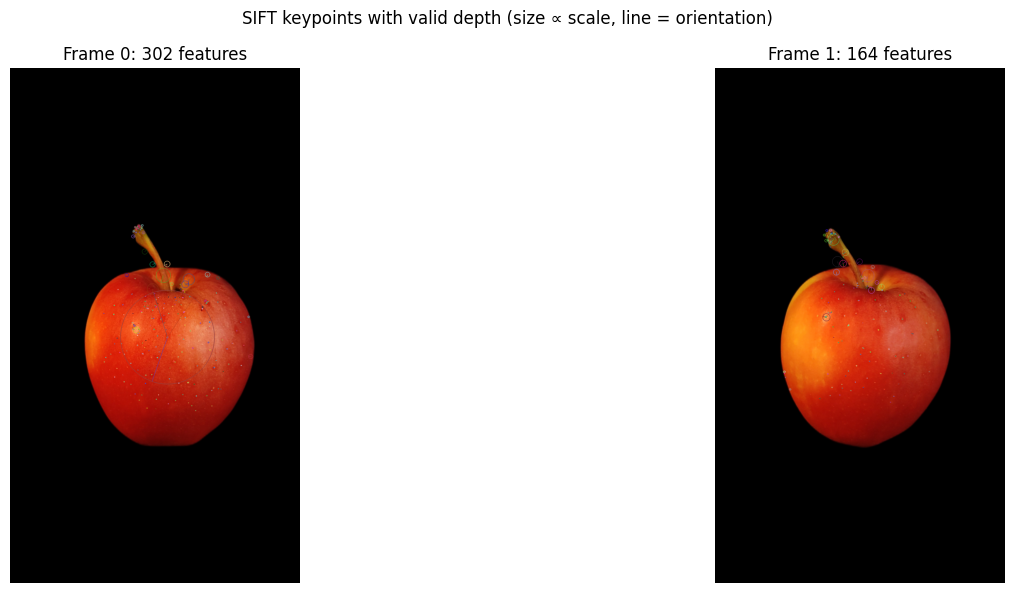

In [12]:
## ── DEBUG: SIFT Feature Extraction ──────────────────────────────────────────
DBG_SRC, DBG_TGT = 0, 1   # frame indices to inspect throughout debug cells

img_s, img_t     = images[DBG_SRC],     images[DBG_TGT]
depth_s, depth_t = depth_maps[DBG_SRC], depth_maps[DBG_TGT]

kps_s, descs_s, pts3d_s = extract_sift_features_3d(img_s, depth_s, fx, fy, cx, cy)
kps_t, descs_t, pts3d_t = extract_sift_features_3d(img_t, depth_t, fx, fy, cx, cy)

print(f"Frame {DBG_SRC}: {len(kps_s)} SIFT features with valid depth")
print(f"Frame {DBG_TGT}: {len(kps_t)} SIFT features with valid depth")

# Draw keypoints (rich: size + orientation) on both images
draw_flags = cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
kp_vis_s = cv2.drawKeypoints(np.array(img_s), kps_s, None, flags=draw_flags)
kp_vis_t = cv2.drawKeypoints(np.array(img_t), kps_t, None, flags=draw_flags)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].imshow(kp_vis_s);  axes[0].set_title(f"Frame {DBG_SRC}: {len(kps_s)} features");  axes[0].axis('off')
axes[1].imshow(kp_vis_t);  axes[1].set_title(f"Frame {DBG_TGT}: {len(kps_t)} features");  axes[1].axis('off')
plt.suptitle("SIFT keypoints with valid depth (size ∝ scale, line = orientation)")
plt.tight_layout(); plt.show()

## Feature matching + RANSAC inlier/outlier visualization

Ratio-test matches: 13
RANSAC — inliers: 0  |  outliers: 13  |  ratio: 0.0%


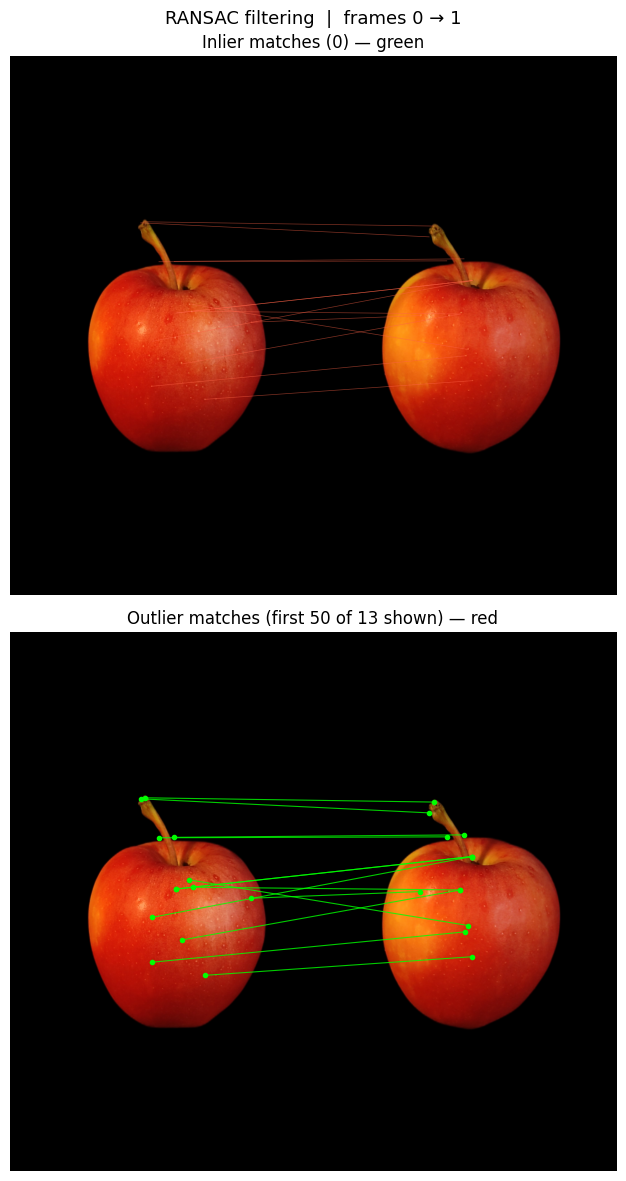

In [13]:
## ── DEBUG: Feature Matching & RANSAC ────────────────────────────────────────
idx_s, idx_t = match_sift_features(descs_s, descs_t, ratio=0.75)
print(f"Ratio-test matches: {len(idx_s)}")

assert len(idx_s) >= 3, "Too few matches for RANSAC — check depth range / ratio threshold."

m3d_s = pts3d_s[np.array(idx_s)]
m3d_t = pts3d_t[np.array(idx_t)]
T_ransac, inlier_mask = ransac_alignment_3d(m3d_s, m3d_t, n_iters=2000, inlier_thresh=0.05)

n_in  = inlier_mask.sum()
n_out = (~inlier_mask).sum()
print(f"RANSAC — inliers: {n_in}  |  outliers: {n_out}  |  ratio: {n_in/len(idx_s):.1%}")

# ── matplotlib match visualisation (green = inlier, red = outlier) ──────────
def _draw_match_lines(ax, img1, img2, kps1, kps2, idx1, idx2, mask,
                      max_outliers=40):
    arr1, arr2 = np.array(img1), np.array(img2)
    h1, w1 = arr1.shape[:2];  h2, w2 = arr2.shape[:2]
    canvas = np.zeros((max(h1, h2), w1 + w2, 3), dtype=np.uint8)
    canvas[:h1, :w1]  = arr1
    canvas[:h2, w1:]  = arr2
    ax.imshow(canvas)
    n_out_drawn = 0
    for i, (qi, ti, is_in) in enumerate(zip(idx1, idx2, mask)):
        x1, y1 = kps1[qi].pt
        x2, y2 = kps2[ti].pt
        x2 += w1
        if is_in:
            ax.plot([x1, x2], [y1, y2], '-', color='lime',   lw=0.8, alpha=0.8)
            ax.plot(x1, y1, 'o', color='lime',   ms=3)
            ax.plot(x2, y2, 'o', color='lime',   ms=3)
        elif n_out_drawn < max_outliers:
            ax.plot([x1, x2], [y1, y2], '-', color='tomato', lw=0.5, alpha=0.5)
            n_out_drawn += 1
    ax.axis('off')

fig, axes = plt.subplots(2, 1, figsize=(18, 12))
_draw_match_lines(axes[0], img_s, img_t, kps_s, kps_t, idx_s, idx_t,  inlier_mask)
axes[0].set_title(f"Inlier matches ({n_in}) — green")
_draw_match_lines(axes[1], img_s, img_t, kps_s, kps_t, idx_s, idx_t, ~inlier_mask, max_outliers=50)
axes[1].set_title(f"Outlier matches (first 50 of {n_out} shown) — red")
plt.suptitle(f"RANSAC filtering  |  frames {DBG_SRC} → {DBG_TGT}", fontsize=13)
plt.tight_layout(); plt.show()

## Point-cloud alignment at each stage

ICP  fitness=0.9441  RMSE=0.01462 m


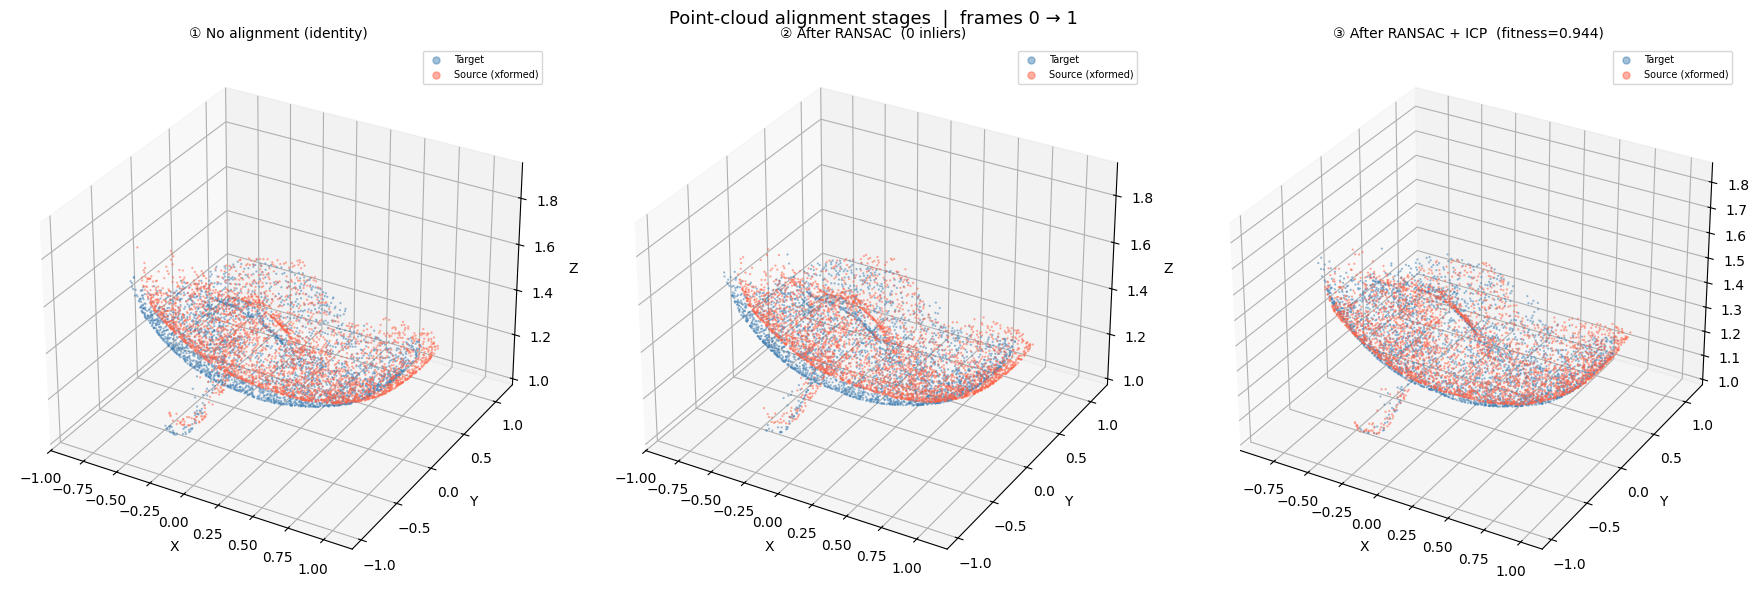

In [14]:
## ── DEBUG: Alignment Before/After RANSAC/ICP ────────────────────────────────
VOXEL_SIZE      = 0.02
ICP_DIST_THRESH = VOXEL_SIZE * 2.5

pcd_s = pcd_from_rgbd(depth_s, img_s, fx, fy, cx, cy, voxel_size=VOXEL_SIZE)
pcd_t = pcd_from_rgbd(depth_t, img_t, fx, fy, cx, cy, voxel_size=VOXEL_SIZE)

icp_result = rgbd_icp_align(pcd_s, pcd_t, init_T=T_ransac,
                             max_iter=50, distance_thresh=ICP_DIST_THRESH)
T_icp = icp_result.transformation
print(f"ICP  fitness={icp_result.fitness:.4f}  RMSE={icp_result.inlier_rmse:.5f} m")

# ── 3-D scatter: compare the three stages side-by-side ──────────────────────
def _scatter_clouds(ax, pts_src, pts_tgt, T, title, n_pts=3000):
    si = np.random.choice(len(pts_src), min(n_pts, len(pts_src)), replace=False)
    ti = np.random.choice(len(pts_tgt), min(n_pts, len(pts_tgt)), replace=False)
    src_t = apply_transform(T, pts_src[si])
    ax.scatter(*pts_tgt[ti].T,  s=0.4, c='steelblue', alpha=0.5, label='Target')
    ax.scatter(*src_t.T,         s=0.4, c='tomato',    alpha=0.5, label='Source (xformed)')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.legend(markerscale=8, fontsize=7)

pts_s_arr = np.asarray(pcd_s.points)
pts_t_arr = np.asarray(pcd_t.points)

stages = [
    (np.eye(4),  "① No alignment (identity)"),
    (T_ransac,   f"② After RANSAC  ({n_in} inliers)"),
    (T_icp,      f"③ After RANSAC + ICP  (fitness={icp_result.fitness:.3f})"),
]

fig = plt.figure(figsize=(18, 6))
for k, (T, label) in enumerate(stages):
    ax = fig.add_subplot(1, 3, k+1, projection='3d')
    _scatter_clouds(ax, pts_s_arr, pts_t_arr, T, label)

plt.suptitle(f"Point-cloud alignment stages  |  frames {DBG_SRC} → {DBG_TGT}", fontsize=13)
plt.tight_layout(); plt.show()

## Full sequential RGBD-ICP pipeline

In [15]:
## ── FULL PIPELINE: Sequential RGBD-ICP ──────────────────────────────────────
VOXEL_SIZE         = 0.02
ICP_DIST_THRESH    = VOXEL_SIZE * 2.5
RANSAC_THRESH      = 0.05
N_RANSAC_ITERS     = 10000
RANSAC_MIN_INLIERS = 3          # fall back to motion model below this
ICP_MIN_FITNESS    = 0.20       # warn if ICP quality is poor

# Pre-build all downsampled + normal-estimated clouds once
print("Building point clouds…")
all_pcds = [
    pcd_from_rgbd(d, img, fx, fy, cx, cy, voxel_size=VOXEL_SIZE)
    for d, img in zip(depth_maps, images)
]

# Pre-extract 3-D SIFT features for every frame
print("Extracting SIFT features…")
all_kps, all_descs, all_pts3d = [], [], []
for img, depth in zip(images, depth_maps):
    kps, descs, pts3d = extract_sift_features_3d(img, depth, fx, fy, cx, cy)
    all_kps.append(kps);  all_descs.append(descs);  all_pts3d.append(pts3d)
    print(f"  {len(kps)} features", end="  ")
print()

# ── Sequential alignment loop ────────────────────────────────────────────────
global_transforms   = [np.eye(4)]   # world ← frame_i
local_transforms    = [np.eye(4)]   # frame_i-1 ← frame_i (relative)
last_local_T        = np.eye(4)     # for constant-velocity fallback

stats = []

for i in range(len(images) - 1):
    src_pcd, tgt_pcd = all_pcds[i], all_pcds[i + 1]

    # Step 1+2: Match 3-D SIFT features
    idx_i, idx_j = match_sift_features(all_descs[i], all_descs[i+1], ratio=0.75)

    # Step 3: RANSAC for initial rigid transform
    n_inliers = 0
    init_T    = last_local_T           # constant-velocity fallback by default

    if len(idx_i) >= 3:
        m_s = all_pts3d[i  ][np.array(idx_i)]
        m_t = all_pts3d[i+1][np.array(idx_j)]
        T_ransac_i, mask_i = ransac_alignment_3d(m_s, m_t,
                                                   n_iters=N_RANSAC_ITERS,
                                                   inlier_thresh=RANSAC_THRESH)
        n_inliers = mask_i.sum()
        if n_inliers >= RANSAC_MIN_INLIERS:
            init_T = T_ransac_i

    fallback_used = (n_inliers < RANSAC_MIN_INLIERS)

    # Steps 4-7: Point-to-plane ICP loop
    icp_res = rgbd_icp_align(src_pcd, tgt_pcd, init_T=init_T,
                              max_iter=50, distance_thresh=ICP_DIST_THRESH)
    T_local = icp_res.transformation

    # Update motion model with successful estimates
    if icp_res.fitness >= ICP_MIN_FITNESS:
        last_local_T = T_local

    # Accumulate global pose
    T_global = global_transforms[-1] @ T_local
    global_transforms.append(T_global)
    local_transforms.append(T_local)

    stats.append({
        "pair"      : f"{i}→{i+1}",
        "matches"   : len(idx_i),
        "inliers"   : n_inliers,
        "fallback"  : fallback_used,
        "fitness"   : icp_res.fitness,
        "rmse"      : icp_res.inlier_rmse,
    })

    flag = " ⚠ fallback" if fallback_used else ""
    flag += " ⚠ poor ICP" if icp_res.fitness < ICP_MIN_FITNESS else ""
    print(f"Pair {i}→{i+1}: {len(idx_i):4d} matches | "
          f"{n_inliers:3d} RANSAC inliers | "
          f"ICP fitness={icp_res.fitness:.3f}  RMSE={icp_res.inlier_rmse:.5f}{flag}")

print("\nPipeline complete.")

Building point clouds…
Extracting SIFT features…
  302 features    164 features    184 features    141 features    133 features    212 features    263 features    472 features    343 features    256 features    304 features    343 features  
Pair 0→1:   13 matches |   0 RANSAC inliers | ICP fitness=0.944  RMSE=0.01462 ⚠ fallback
Pair 1→2:   10 matches |   3 RANSAC inliers | ICP fitness=0.917  RMSE=0.01362
Pair 2→3:   16 matches |   5 RANSAC inliers | ICP fitness=0.558  RMSE=0.01420
Pair 3→4:   13 matches |   5 RANSAC inliers | ICP fitness=0.934  RMSE=0.01471
Pair 4→5:   12 matches |   5 RANSAC inliers | ICP fitness=0.994  RMSE=0.01540
Pair 5→6:   17 matches |   8 RANSAC inliers | ICP fitness=0.971  RMSE=0.01440
Pair 6→7:   11 matches |   7 RANSAC inliers | ICP fitness=0.977  RMSE=0.01326
Pair 7→8:   51 matches |  35 RANSAC inliers | ICP fitness=0.969  RMSE=0.01375
Pair 8→9:   32 matches |  12 RANSAC inliers | ICP fitness=0.899  RMSE=0.01414
Pair 9→10:   30 matches |  13 RANSAC inliers 

## Camera trajectory visualization

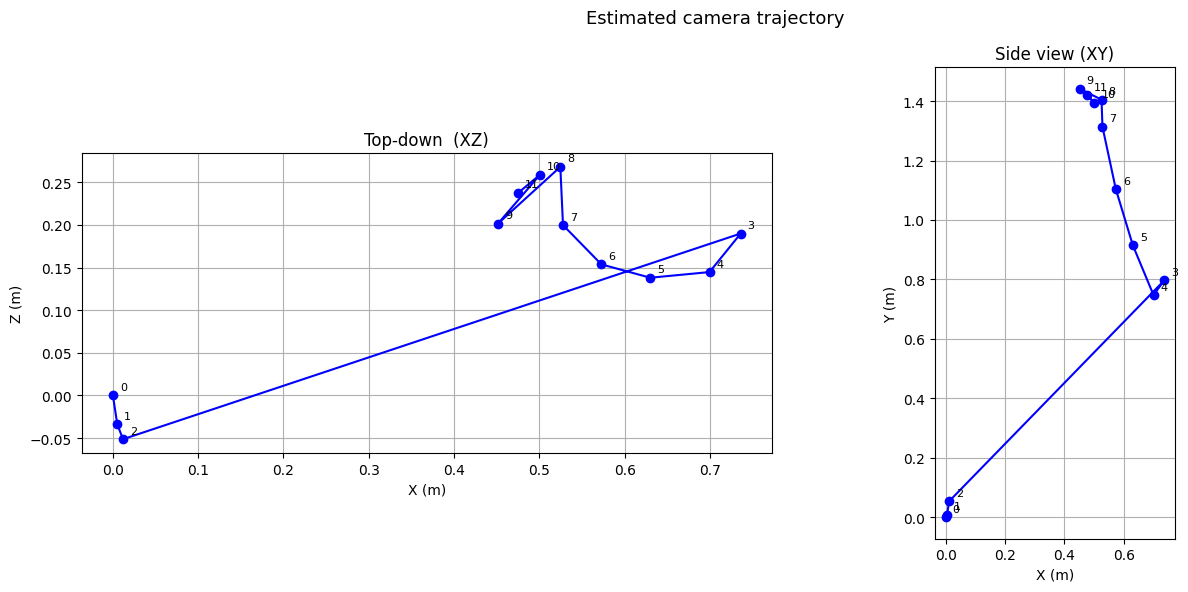

In [16]:
## ── DEBUG: Camera trajectory ─────────────────────────────────────────────────
positions = np.array([T[:3, 3] for T in global_transforms])   # (N,3)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (xi, yi, xlabel, ylabel, title) in zip(axes, [
    (0, 2, "X (m)", "Z (m)", "Top-down  (XZ)"),
    (0, 1, "X (m)", "Y (m)", "Side view (XY)"),
]):
    ax.plot(positions[:, xi], positions[:, yi], 'b-o', ms=6, lw=1.5)
    for k, pos in enumerate(positions):
        ax.annotate(str(k), (pos[xi], pos[yi]), textcoords="offset points",
                    xytext=(5, 4), fontsize=8)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.set_title(title); ax.set_aspect('equal'); ax.grid(True)

plt.suptitle("Estimated camera trajectory", fontsize=13)
plt.tight_layout(); plt.show()

## Keyframe selection + loop closure detection

In [17]:
## ── KEYFRAME SELECTION ────────────────────────────────────────────────────────
# A new keyframe is created when a frame can no longer be matched against
# the previous keyframe with enough RANSAC inliers (i.e. visual overlap has dropped).
KEYFRAME_MIN_INLIERS = 20    # inliers vs. prev KF; below this → emit a new keyframe
LOOP_MIN_INLIERS     = 12    # inliers needed to add a loop-closure edge
N_RANSAC_LOOP        = 3000

keyframes = [0]   # absolute frame indices of all keyframes
prev_kf   = 0

print("Selecting keyframes…")
for i in range(1, len(images)):
    idx_i, idx_j = match_sift_features(all_descs[prev_kf], all_descs[i], ratio=0.75)
    n_inliers = 0
    if len(idx_i) >= 3:
        m_s = all_pts3d[prev_kf][np.array(idx_i)]
        m_t = all_pts3d[i      ][np.array(idx_j)]
        _, kf_mask = ransac_alignment_3d(m_s, m_t, n_iters=N_RANSAC_LOOP,
                                         inlier_thresh=RANSAC_THRESH)
        n_inliers = int(kf_mask.sum())

    if n_inliers < KEYFRAME_MIN_INLIERS:
        keyframes.append(i)
        prev_kf = i
        note = "→ NEW KEYFRAME"
    else:
        note = f"(linked to KF {prev_kf} with {n_inliers} inliers)"
    print(f"  Frame {i:2d}: {n_inliers:3d} inliers vs KF {prev_kf}  {note}")

print(f"\nKeyframes ({len(keyframes)}): {keyframes}")

# ── Loop closure: check every non-adjacent keyframe pair ─────────────────────
# For a turntable (≤12 frames), the O(k²) all-pairs check is fast enough.
# For large sequences, gate by distance: np.linalg.norm(pos_ki - pos_kj) < MAX_DIST
loop_closure_edges = []
print("\nDetecting loop closures between keyframes…")

for ki_idx in range(1, len(keyframes)):
    ki = keyframes[ki_idx]
    for kj_idx in range(ki_idx - 1):   # skip immediately adjacent KF (already an odometry edge)
        kj = keyframes[kj_idx]

        idx_i, idx_j = match_sift_features(all_descs[ki], all_descs[kj], ratio=0.75)
        if len(idx_i) < 3:
            continue

        m_s = all_pts3d[ki][np.array(idx_i)]
        m_t = all_pts3d[kj][np.array(idx_j)]
        T_lc, lc_mask = ransac_alignment_3d(m_s, m_t, n_iters=N_RANSAC_LOOP,
                                             inlier_thresh=RANSAC_THRESH)
        n_lc = int(lc_mask.sum())

        if n_lc >= LOOP_MIN_INLIERS:
            icp_lc = rgbd_icp_align(all_pcds[ki], all_pcds[kj],
                                    init_T=T_lc, max_iter=50,
                                    distance_thresh=ICP_DIST_THRESH)
            loop_closure_edges.append({
                'source' : ki,
                'target' : kj,
                'T'      : icp_lc.transformation,
                'fitness': icp_lc.fitness,
                'inliers': n_lc,
            })
            print(f"  ✓ Loop closure: frame {ki:2d} ↔ frame {kj:2d}  "
                  f"RANSAC inliers={n_lc:3d}  ICP fitness={icp_lc.fitness:.3f}")
        else:
            print(f"  ✗ Rejected:     frame {ki:2d} ↔ frame {kj:2d}  "
                  f"RANSAC inliers={n_lc:3d} (< {LOOP_MIN_INLIERS})")

print(f"\n{len(loop_closure_edges)} loop-closure edge(s) detected.")

Selecting keyframes…
  Frame  1:   0 inliers vs KF 1  → NEW KEYFRAME
  Frame  2:   3 inliers vs KF 2  → NEW KEYFRAME
  Frame  3:   5 inliers vs KF 3  → NEW KEYFRAME
  Frame  4:   6 inliers vs KF 4  → NEW KEYFRAME
  Frame  5:   5 inliers vs KF 5  → NEW KEYFRAME
  Frame  6:   8 inliers vs KF 6  → NEW KEYFRAME
  Frame  7:   7 inliers vs KF 7  → NEW KEYFRAME
  Frame  8:  35 inliers vs KF 7  (linked to KF 7 with 35 inliers)
  Frame  9:   4 inliers vs KF 9  → NEW KEYFRAME
  Frame 10:  13 inliers vs KF 10  → NEW KEYFRAME
  Frame 11:  28 inliers vs KF 10  (linked to KF 10 with 28 inliers)

Keyframes (10): [0, 1, 2, 3, 4, 5, 6, 7, 9, 10]

Detecting loop closures between keyframes…
  ✗ Rejected:     frame  3 ↔ frame  1  RANSAC inliers=  0 (< 12)
  ✗ Rejected:     frame  4 ↔ frame  0  RANSAC inliers=  0 (< 12)
  ✗ Rejected:     frame  4 ↔ frame  1  RANSAC inliers=  3 (< 12)
  ✗ Rejected:     frame  4 ↔ frame  2  RANSAC inliers=  0 (< 12)
  ✗ Rejected:     frame  5 ↔ frame  0  RANSAC inliers=  3 (

## Pose graph construction + global optimization (≡ TORO)

In [18]:
## ── POSE GRAPH CONSTRUCTION ───────────────────────────────────────────────────
# Convention (Open3D multiway registration):
#   PoseGraphNode.pose = inv(accumulated_odometry)
#   PoseGraphEdge.transformation = raw ICP/RANSAC result (source → target)
#   uncertain=False  → odometry (sequential) edge
#   uncertain=True   → loop-closure edge (may be pruned by optimizer)

pose_graph = o3d.pipelines.registration.PoseGraph()

# Nodes ───────────────────────────────────────────────────────────────────────
for T in global_transforms:
    pose_graph.nodes.append(
        o3d.pipelines.registration.PoseGraphNode(np.linalg.inv(T))
    )

# Sequential (odometry) edges ─────────────────────────────────────────────────
for i in range(len(images) - 1):
    T_rel = local_transforms[i + 1]
    info  = o3d.pipelines.registration.get_information_matrix_from_point_clouds(
        all_pcds[i], all_pcds[i + 1], ICP_DIST_THRESH * 1.4, T_rel
    )
    pose_graph.edges.append(
        o3d.pipelines.registration.PoseGraphEdge(
            source_node_id=i,
            target_node_id=i + 1,
            transformation=T_rel,
            information=info,
            uncertain=False,
        )
    )

# Loop-closure edges ──────────────────────────────────────────────────────────
for lc in loop_closure_edges:
    info = o3d.pipelines.registration.get_information_matrix_from_point_clouds(
        all_pcds[lc['source']], all_pcds[lc['target']],
        ICP_DIST_THRESH * 1.4, lc['T']
    )
    pose_graph.edges.append(
        o3d.pipelines.registration.PoseGraphEdge(
            source_node_id=lc['source'],
            target_node_id=lc['target'],
            transformation=lc['T'],
            information=info,
            uncertain=True,          # optimizer may prune if inconsistent
        )
    )

print(f"Pose graph: {len(pose_graph.nodes)} nodes | "
      f"{len(images)-1} odometry edges | {len(loop_closure_edges)} loop-closure edges")

# ── Global optimization (Levenberg-Marquardt, equivalent to TORO) ────────────
option = o3d.pipelines.registration.GlobalOptimizationOption(
    max_correspondence_distance=ICP_DIST_THRESH * 1.4,
    edge_prune_threshold=0.25,   # prune loop edges with high residual
    reference_node=0,
)

o3d.utility.set_verbosity_level(o3d.utility.VerbosityLevel.Error)   # suppress internal logs
o3d.pipelines.registration.global_optimization(
    pose_graph,
    o3d.pipelines.registration.GlobalOptimizationLevenbergMarquardt(),
    o3d.pipelines.registration.GlobalOptimizationConvergenceCriteria(),
    option,
)
o3d.utility.set_verbosity_level(o3d.utility.VerbosityLevel.Warning)

# Extract corrected global transforms (same convention as global_transforms)
optimized_transforms = [np.linalg.inv(node.pose) for node in pose_graph.nodes]
print("Pose graph optimization complete.")

Pose graph: 12 nodes | 11 odometry edges | 1 loop-closure edges
Pose graph optimization complete.


## Pose graph + before/after trajectory

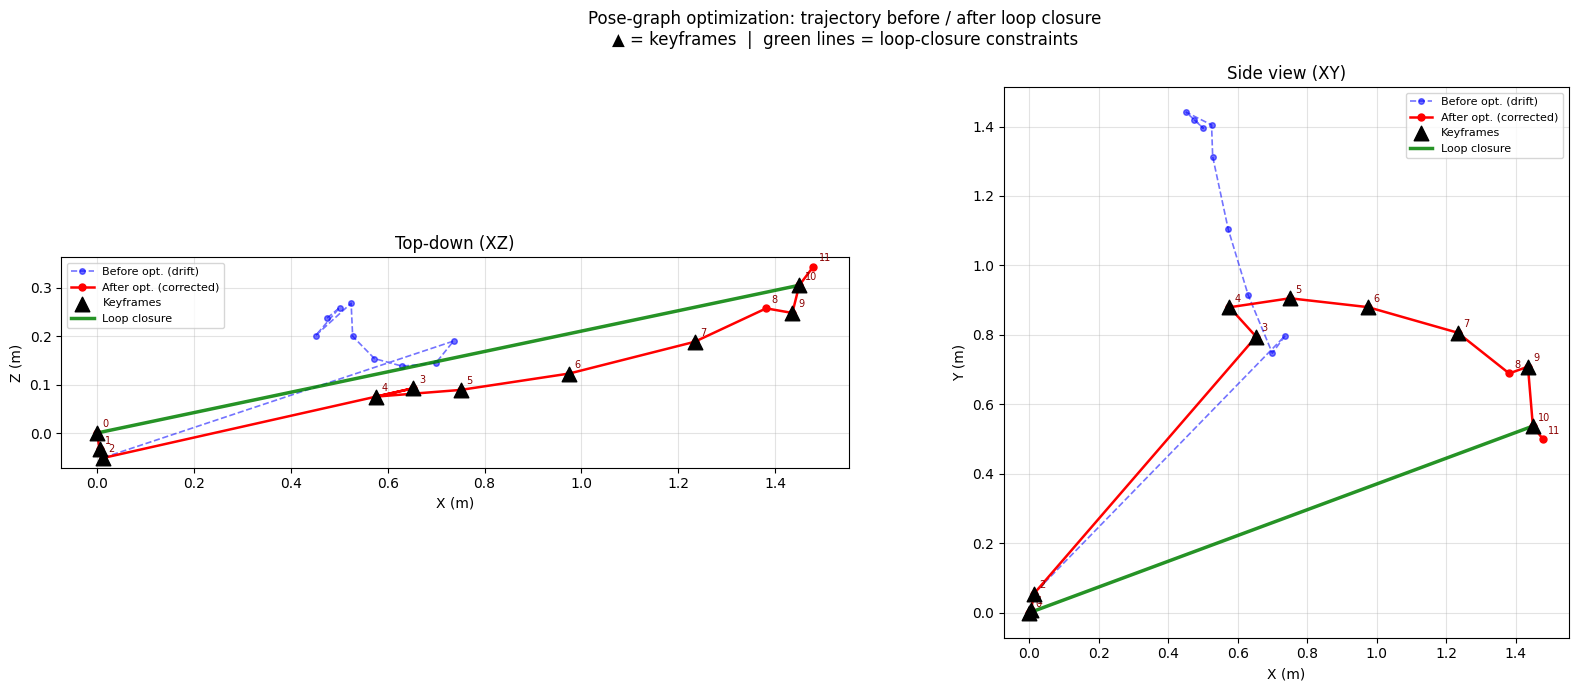

First↔Last frame distance  before opt: 1.5157 m  (turntable drift)
First↔Last frame distance  after  opt: 1.5981 m  (loop closed)

Edge             Source Target  Inliers  Fitness
──────────────────────────────────────────────────
Odometry              0      1        0    0.944
Odometry              1      2        3    0.917
Odometry              2      3        5    0.558
Odometry              3      4        5    0.934
Odometry              4      5        5    0.994
Odometry              5      6        8    0.971
Odometry              6      7        7    0.977
Odometry              7      8       35    0.969
Odometry              8      9       12    0.899
Odometry              9     10       13    0.973
Odometry             10     11       28    0.978
LoopClosure          10      0       21    0.983


In [19]:
## ── DEBUG: Pose Graph Topology + Trajectory Before/After ────────────────────
pos_before = np.array([T[:3, 3] for T in global_transforms])
pos_after  = np.array([T[:3, 3] for T in optimized_transforms])

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
view_specs = [
    (0, 2, "X (m)", "Z (m)", "Top-down (XZ)"),
    (0, 1, "X (m)", "Y (m)", "Side view (XY)"),
]

for ax, (xi, yi, xlabel, ylabel, title) in zip(axes, view_specs):
    # Drifted trajectory
    ax.plot(pos_before[:, xi], pos_before[:, yi],
            'b--o', ms=4, lw=1.2, alpha=0.55, label='Before opt. (drift)')
    # Corrected trajectory
    ax.plot(pos_after[:, xi], pos_after[:, yi],
            'r-o', ms=5, lw=1.8, label='After opt. (corrected)')

    # Frame index labels on corrected trajectory
    for k in range(len(pos_after)):
        ax.annotate(str(k), (pos_after[k, xi], pos_after[k, yi]),
                    textcoords="offset points", xytext=(4, 4),
                    fontsize=7, color='darkred')

    # Keyframes
    kf_pos = pos_after[keyframes]
    ax.scatter(kf_pos[:, xi], kf_pos[:, yi],
               marker='^', s=110, c='black', zorder=6, label='Keyframes')

    # Loop-closure edges
    first_lc = True
    for lc in loop_closure_edges:
        xs = [pos_after[lc['source'], xi], pos_after[lc['target'], xi]]
        ys = [pos_after[lc['source'], yi], pos_after[lc['target'], yi]]
        label = 'Loop closure' if first_lc else None
        ax.plot(xs, ys, 'g-', lw=2.5, alpha=0.85, label=label, zorder=5)
        first_lc = False

    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.set_title(title); ax.set_aspect('equal'); ax.grid(True, alpha=0.35)
    ax.legend(fontsize=8)

plt.suptitle(
    "Pose-graph optimization: trajectory before / after loop closure\n"
    "▲ = keyframes  |  green lines = loop-closure constraints",
    fontsize=12,
)
plt.tight_layout()
plt.show()

# ── Numeric summary ──────────────────────────────────────────────────────────
drift_before = np.linalg.norm(pos_before[-1] - pos_before[0])
drift_after  = np.linalg.norm(pos_after [-1] - pos_after [0])
print(f"First↔Last frame distance  before opt: {drift_before:.4f} m  (turntable drift)")
print(f"First↔Last frame distance  after  opt: {drift_after :.4f} m  (loop closed)")
print()
print(f"{'Edge':<16} {'Source':>6} {'Target':>6} {'Inliers':>8} {'Fitness':>8}")
print("─" * 50)
for i in range(len(images) - 1):
    print(f"{'Odometry':<16} {i:>6} {i+1:>6} {stats[i]['inliers']:>8} {stats[i]['fitness']:>8.3f}")
for lc in loop_closure_edges:
    print(f"{'LoopClosure':<16} {lc['source']:>6} {lc['target']:>6} {lc['inliers']:>8} {lc['fitness']:>8.3f}")

## Merge, save, and visualize the full reconstruction

In [20]:
## ── MERGE WITH LOOP-CLOSURE-CORRECTED POSES ──────────────────────────────────
merged_opt = o3d.geometry.PointCloud()
for pcd, T in zip(all_pcds, optimized_transforms):
    merged_opt += copy.deepcopy(pcd).transform(T)

merged_opt = merged_opt.voxel_down_sample(VOXEL_SIZE)
merged_opt, _ = merged_opt.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)
print(f"Optimized reconstruction: {len(merged_opt.points):,} points")

out_path = "../results/rgbd_turntable/rgbd_icp_loop_closure.ply"
o3d.io.write_point_cloud(out_path, merged_opt)
print(f"Saved → {out_path}")

o3d.visualization.draw_geometries([merged_opt], window_name="RGBD-ICP + Loop Closure")

Optimized reconstruction: 83,429 points
Saved → ../results/rgbd_turntable/rgbd_icp_loop_closure.ply
